<a href="https://colab.research.google.com/github/ASHIKAJAN/Real_Estate_Price_Prediction.ipynb/blob/real-estate/Real_Estate_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***MINI PROJECT  ----> Real_Estate_Price_Prediction***

***INTRODUCTION*** --->
Real estate pricing depends on multiple factors like location, area, and amenities..

***PROBLEM STATEMENT*** --->
Accurately determining property value is difficult due to multiple influencing factors...

***OBJECTIVES*** --->
Analyze dataset,
Find key factors affecting price,
Build ML model

***DATASET DESCRIPTION*** --->
Rows: 10,000+,
Columns: (mention features like City, Area, Bedrooms etc.),
Target: Price_INR


In [2]:
from google.colab import files
uploaded = files.upload()

Saving real_estate_dataset_10000_rows.csv to real_estate_dataset_10000_rows.csv


***DATA PREPROCESSING***

In [3]:
import pandas as pd
df = pd.read_csv("real_estate_dataset_10000_rows.csv")
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Property_ID          10000 non-null  int64  
 1   City                 10000 non-null  object 
 2   Location_Type        10000 non-null  object 
 3   Property_Type        10000 non-null  object 
 4   Bedrooms             10000 non-null  int64  
 5   Bathrooms            10000 non-null  int64  
 6   Area_sqft            10000 non-null  int64  
 7   Age_of_Property      10000 non-null  int64  
 8   Floor_Number         10000 non-null  int64  
 9   Total_Floors         10000 non-null  int64  
 10  Parking_Spaces       10000 non-null  int64  
 11  Nearby_Schools_km    10000 non-null  float64
 12  Nearby_Hospitals_km  10000 non-null  float64
 13  Price_INR            10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,0
Property_ID,0
City,0
Location_Type,0
Property_Type,0
Bedrooms,0
Bathrooms,0
Area_sqft,0
Age_of_Property,0
Floor_Number,0
Total_Floors,0


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["City"] = le.fit_transform(df["City"])
df["Property_Type"] = le.fit_transform(df["Property_Type"])
df["Location_Type"] = le.fit_transform(df["Location_Type"])

***EXPLORATORY DATA ANALYSIS***

Visualization 1: Price Distribution

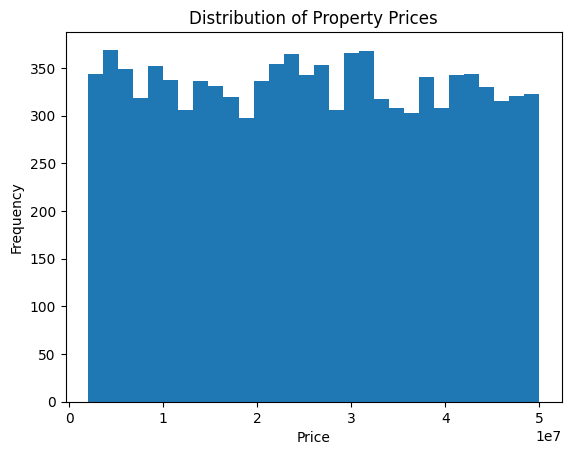

In [8]:
import matplotlib.pyplot as plt

plt.hist(df["Price_INR"], bins=30)
plt.title("Distribution of Property Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


Visualization 2: Area vs Price

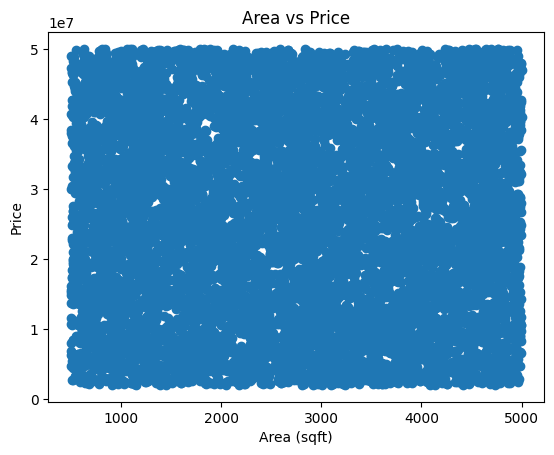

In [9]:
plt.scatter(df["Area_sqft"], df["Price_INR"])
plt.xlabel("Area (sqft)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()


Visualization 3: City-wise Price

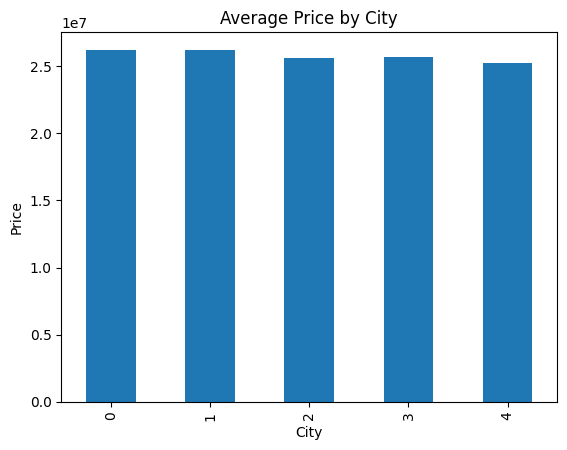

In [10]:
city_price = df.groupby("City")["Price_INR"].mean()
city_price.plot(kind="bar")
plt.title("Average Price by City")
plt.ylabel("Price")
plt.show()


Visualisation 4:Bedrooms vs Price

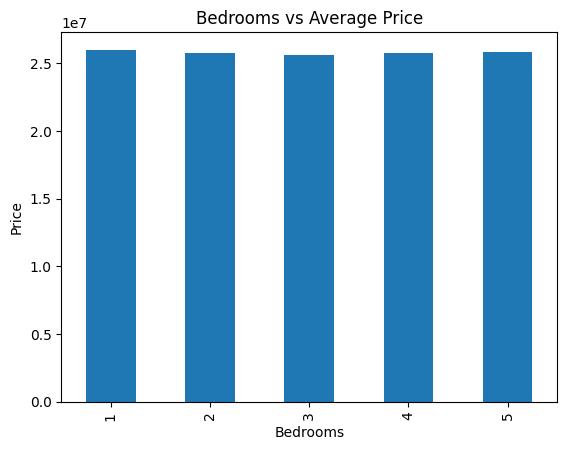

In [11]:
bed_price = df.groupby("Bedrooms")["Price_INR"].mean()
bed_price.plot(kind="bar")
plt.title("Bedrooms vs Average Price")
plt.ylabel("Price")
plt.show()


In [12]:
df["Price_per_sqft"] = df["Price_INR"] / df["Area_sqft"]

***MODEL BUILDING***

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("Price_INR", axis=1)
y = df["Price_INR"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

***LINEAR REGRESSION***

In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

***MODEL***

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

***MODEL EVALUATION***

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 246883.92084
R2 Score: 0.9991914125748012
